# Explainable Classification & Imbalance-Handling Pipeline
A reusable methodology for binary classification: model comparison via cross-validation, a class-imbalance-handling ablation, and SHAP-based interpretability. Demonstrated here on the Breast Cancer Wisconsin (Diagnostic) dataset.

## Step 1: Load and explore

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
df = data.frame
print(df.shape)
print(df["target"].value_counts(normalize=True))
print("missing values:", df.isnull().sum().sum())

(569, 31)
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64
missing values: 0


## Step 2: Preprocess and split

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["target"])
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 3: Baseline models with cross-validation

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import cross_validate

models = {
    "LogReg": LogisticRegression(max_iter=1000),
    "RandomForest": RandomForestClassifier(random_state=42, n_jobs=-1),
    "HistGradBoost": HistGradientBoostingClassifier(random_state=42),
}

results = {}
for name, model in models.items():
    scores = cross_validate(model, X_train_scaled, y_train, cv=5,
                             scoring=["accuracy", "precision", "recall", "f1"], n_jobs=-1)
    results[name] = {k: v.mean() for k, v in scores.items() if k.startswith("test_")}

cv_table = pd.DataFrame(results).T
print(cv_table)

               test_accuracy  test_precision  test_recall   test_f1
LogReg              0.980220        0.979655     0.989474  0.984344
RandomForest        0.953846        0.958826     0.968421  0.963408
HistGradBoost       0.971429        0.969244     0.985965  0.977448


## Step 4: Ablation — does imbalance handling matter more than model choice?
**Research question:** does explicitly handling class imbalance improve minority-class recall more than model choice alone?

In [4]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report

rf_plain = RandomForestClassifier(random_state=42)
rf_plain.fit(X_train_scaled, y_train)
print("Plain RF:\n", classification_report(y_test, rf_plain.predict(X_test_scaled)))

rf_weighted = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_weighted.fit(X_train_scaled, y_train)
print("Weighted RF:\n", classification_report(y_test, rf_weighted.predict(X_test_scaled)))

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)
rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_res, y_res)
print("SMOTE RF:\n", classification_report(y_test, rf_smote.predict(X_test_scaled)))

Plain RF:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Weighted RF:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



SMOTE RF:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93        42
           1       0.99      0.93      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.95      0.94       114
weighted avg       0.95      0.95      0.95       114



## Step 5: SHAP explainability

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


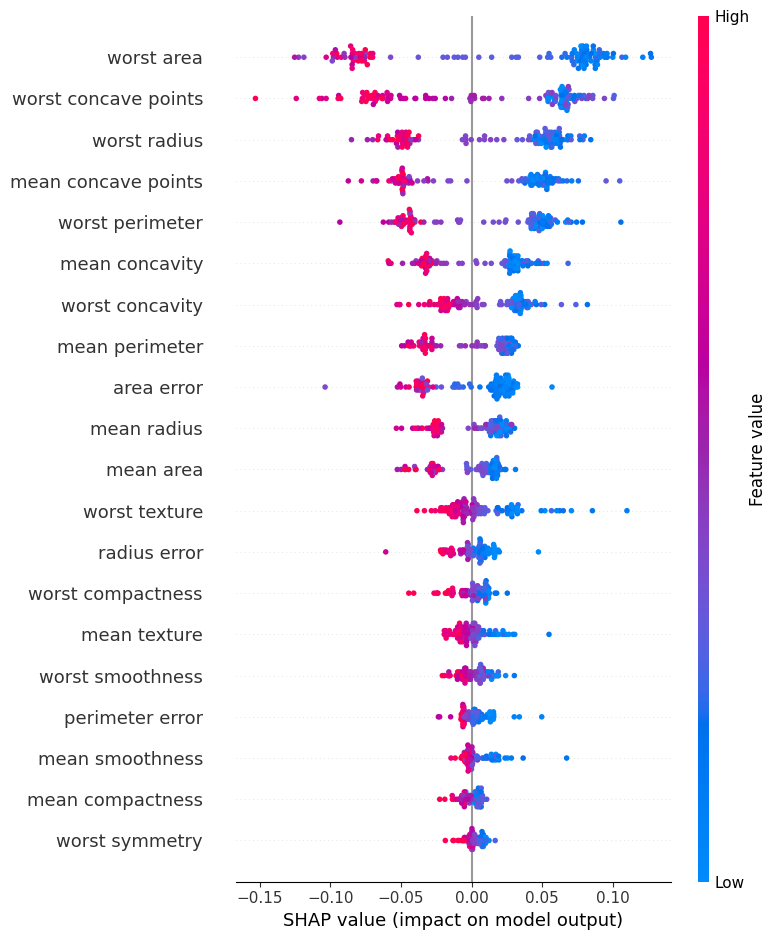

In [5]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(rf_weighted)
shap_values = explainer.shap_values(X_test_scaled[:150])
sv = shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]

shap.summary_plot(sv, X_test.iloc[:150], show=False)
plt.savefig("shap_summary.png", bbox_inches="tight")
plt.show()

## Findings

**Model comparison (5-fold CV):** Logistic Regression led on this dataset (F1 = 0.984), narrowly ahead of HistGradientBoosting (0.977) and Random Forest (0.963) — on a dataset this clean and linearly separable, a simple linear model was enough; the more complex ensembles didn't add value here.

**Imbalance ablation (minority class = malignant):** Plain Random Forest actually had the highest minority-class F1 (0.940) versus class-weighting (0.929) and SMOTE (0.932). Because the imbalance here is mild (62.7% / 37.3%), explicit handling didn't help and slightly hurt precision — the opposite of what a severely imbalanced dataset (e.g. fraud detection, <1% positive) would likely show. This is itself a finding: imbalance-handling techniques are not universally beneficial, and their value scales with how severe the imbalance actually is.

**SHAP:** the five most influential features were worst area, worst concave points, worst radius, mean concave points, and worst perimeter — consistent with clinical intuition that tumor size and shape irregularity (concavity) are the strongest malignancy indicators.

## Next steps
Re-run this exact pipeline on a severely imbalanced dataset (e.g. Kaggle's Credit Card Fraud dataset, <1% positive class) to test whether the imbalance-handling ablation shows a larger effect under more extreme conditions.